# Statistical Validation (Spark-first)

## Objective
Validate whether airline delay patterns are statistically significant.

### Tests
1) Chi-square: Airline vs Delay (arrival)
2) ANOVA: Airline vs Arrival Delay minutes
3) Congestion vs Arrival Delay (Correlation)

### Why Spark-first?
Because dataset is large. We sample per airline using Spark, then run statistical tests on manageable data.

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from pyspark.sql import functions as F
from pyspark.sql.window import Window

In [0]:
# Your main cleaned table
df = spark.table("tables.default.finally_cleaned_data")

# Quick sanity check
display(df.select("AIRLINE", "ARRIVAL_DELAY", "IS_DELAYED_ARRIVAL", "ORIGIN_CONGESTION").limit(5))

AIRLINE,ARRIVAL_DELAY,IS_DELAYED_ARRIVAL,ORIGIN_CONGESTION
AS,4.0,0,1059
B6,46.0,1,1059
DL,0.0,0,1059
DL,-19.0,0,1059
DL,0.0,0,1059


In [0]:
airlines_lookup = [
    ("AA", "American Airlines"),
    ("DL", "Delta Air Lines"),
    ("UA", "United Airlines"),
    ("WN", "Southwest Airlines"),
    ("AS", "Alaska Airlines"),
    ("B6", "JetBlue Airways"),
    ("NK", "Spirit Airlines"),
    ("F9", "Frontier Airlines"),
    ("HA", "Hawaiian Airlines"),
    ("OO", "SkyWest Airlines"),
    ("MQ", "Envoy Air"),
    ("EV", "ExpressJet Airlines"),
    ("US", "US Airways"),
    ("VX", "Virgin America")
]

lookup_df = spark.createDataFrame(airlines_lookup, ["AIRLINE", "AIRLINE_NAME"])

df_labeled = (
    df.join(lookup_df, on="AIRLINE", how="left")
      .withColumn("AIRLINE_NAME", F.coalesce(F.col("AIRLINE_NAME"), F.col("AIRLINE")))  # fallback
)

display(df_labeled.select("AIRLINE", "AIRLINE_NAME").dropDuplicates().orderBy("AIRLINE"))

AIRLINE,AIRLINE_NAME
AA,American Airlines
AS,Alaska Airlines
B6,JetBlue Airways
DL,Delta Air Lines
EV,ExpressJet Airlines
F9,Frontier Airlines
HA,Hawaiian Airlines
MQ,Envoy Air
NK,Spirit Airlines
OO,SkyWest Airlines


## Sampling Strategy (Important)

We do per-airline sampling to avoid converting millions of rows to pandas.
We take up to N rows per airline (example N=20000).

In [0]:
N_PER_AIRLINE = 20000  # you can set 5000/10000 if your compute is small

base = (
    df_labeled
    .select("AIRLINE_NAME", "IS_DELAYED_ARRIVAL", "ARRIVAL_DELAY", "ORIGIN_CONGESTION")
    .filter(F.col("AIRLINE_NAME").isNotNull())
    .filter(F.col("IS_DELAYED_ARRIVAL").isNotNull())
    .filter(F.col("ARRIVAL_DELAY").isNotNull())
    .filter(F.col("ORIGIN_CONGESTION").isNotNull())
)

w = Window.partitionBy("AIRLINE_NAME").orderBy(F.rand(42))

sampled = (
    base.withColumn("rn", F.row_number().over(w))
        .filter(F.col("rn") <= N_PER_AIRLINE)
        .drop("rn")
)

# Check sample size per airline
display(sampled.groupBy("AIRLINE_NAME").count().orderBy(F.desc("count")))

AIRLINE_NAME,count
American Airlines,20000
Envoy Air,20000
SkyWest Airlines,20000
Delta Air Lines,20000
United Airlines,20000
US Airways,20000
Spirit Airlines,20000
ExpressJet Airlines,20000
Alaska Airlines,20000
Virgin America,20000


In [0]:
pdf = sampled.toPandas()
pdf.shape, pdf.head()

((280319, 4),
       AIRLINE_NAME  IS_DELAYED_ARRIVAL  ARRIVAL_DELAY  ORIGIN_CONGESTION
 0  Alaska Airlines                   0          -26.0               1150
 1  Alaska Airlines                   0          -23.0                760
 2  Alaska Airlines                   0            6.0               1027
 3  Alaska Airlines                   0            0.0               1207
 4  Alaska Airlines                   1           40.0                959)

## 1) Chi-square Test: Airline vs Delay (Arrival)

H0: Delay occurrence is independent of airline.  
H1: Delay occurrence depends on airline.

We use IS_DELAYED_ARRIVAL (0/1).

In [0]:
cont = pd.crosstab(pdf["AIRLINE_NAME"], pdf["IS_DELAYED_ARRIVAL"])

chi2, p, dof, expected = stats.chi2_contingency(cont)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

Chi-square statistic: 3844.8813510429204
Degrees of freedom: 14
p-value: 0.0


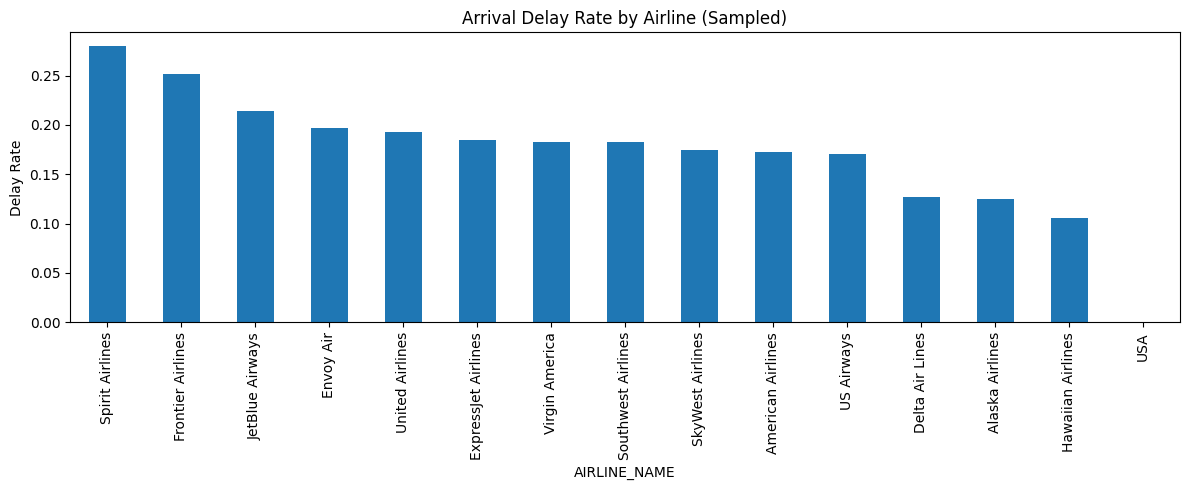

In [0]:
delay_rate = pdf.groupby("AIRLINE_NAME")["IS_DELAYED_ARRIVAL"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
delay_rate.plot(kind="bar")
plt.title("Arrival Delay Rate by Airline (Sampled)")
plt.ylabel("Delay Rate")
plt.tight_layout()
plt.show()

### Interpretation
- If p-value < 0.05 → Reject H0 → Delay rate differs significantly across airlines.
- Use the bar chart to explain which airlines are highest vs lowest.

## 2) ANOVA: Airline vs Arrival Delay Minutes

H0: Mean arrival delay is the same for all airlines.  
H1: At least one airline has a different mean arrival delay.

We use ARRIVAL_DELAY (can be negative too; that’s okay).

In [0]:
groups = [g["ARRIVAL_DELAY"].values for _, g in pdf.groupby("AIRLINE_NAME")]
f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 195.2894997227076
p-value: 0.0


/home/spark-f3564ea4-d2a6-4557-a487-67/.ipykernel/2707/command-4912141401722337-3038010039:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


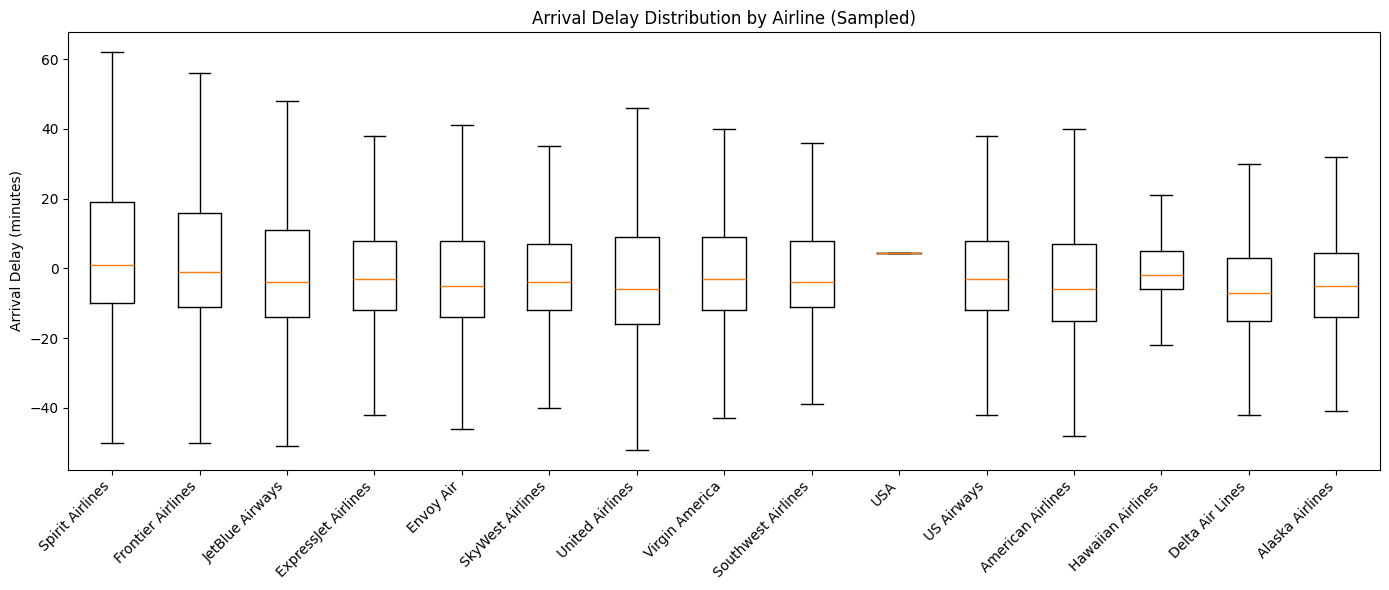

In [0]:
# Prepare data in consistent order
order = pdf.groupby("AIRLINE_NAME")["ARRIVAL_DELAY"].mean().sort_values(ascending=False).index.tolist()
data = [pdf.loc[pdf["AIRLINE_NAME"] == name, "ARRIVAL_DELAY"].values for name in order]

plt.figure(figsize=(14,6))
plt.boxplot(data, labels=order, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.title("Arrival Delay Distribution by Airline (Sampled)")
plt.ylabel("Arrival Delay (minutes)")
plt.tight_layout()
plt.show()

### Interpretation
- Very large F-statistic + very small p-value (often shown as 0.0) means:
  Mean arrival delay differs significantly across airlines (p < 0.001).
- With big datasets, statistical significance is common — so also comment on *practical* differences in mean minutes.

## 3) Correlation: ORIGIN_CONGESTION vs ARRIVAL_DELAY

We check whether congestion is associated with arrival delay.

Correlation coefficient: -0.0009780588749364733


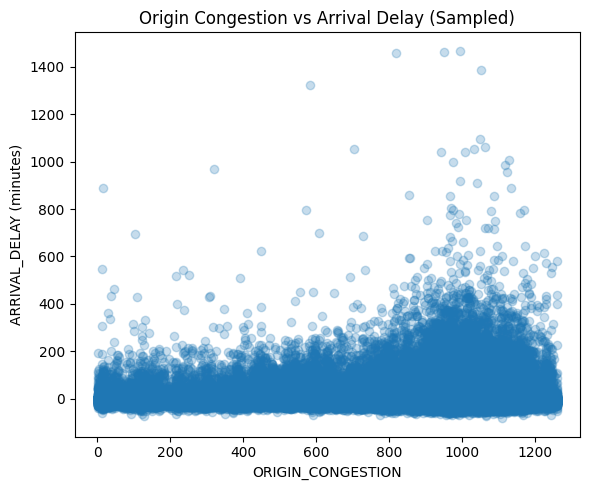

In [0]:
corr = pdf["ORIGIN_CONGESTION"].corr(pdf["ARRIVAL_DELAY"])
print("Correlation coefficient:", corr)

plt.figure(figsize=(6,5))
plt.scatter(pdf["ORIGIN_CONGESTION"], pdf["ARRIVAL_DELAY"], alpha=0.25)
plt.title("Origin Congestion vs Arrival Delay (Sampled)")
plt.xlabel("ORIGIN_CONGESTION")
plt.ylabel("ARRIVAL_DELAY (minutes)")
plt.tight_layout()
plt.show()

# Final Statistical Conclusions

1) Chi-square:
- Confirms whether delay frequency differs by airline.

2) ANOVA:
- Confirms whether mean arrival delay minutes differ by airline.

3) Correlation:
- Indicates whether congestion is linked to higher arrival delays.

These results strengthen the evidence for the predictive modeling phase (Delay + Cancellation prediction).

In [0]:
sorted(pdf["AIRLINE_NAME"].dropna().unique())

['Alaska Airlines',
 'American Airlines',
 'Delta Air Lines',
 'Envoy Air',
 'ExpressJet Airlines',
 'Frontier Airlines',
 'Hawaiian Airlines',
 'JetBlue Airways',
 'SkyWest Airlines',
 'Southwest Airlines',
 'Spirit Airlines',
 'US Airways',
 'USA',
 'United Airlines',
 'Virgin America']